### 1.Modelo de regressão descontínua - Sharp

O conjunto de códigos tem como objetivo seguir algumas orientações do artigo _Regression Discontinuity Designs: A Guide to Practice_, publicado na _Journal of Econometrics_ (v. 142, n. 2, p. 615-635, 2008), dos autores Guido Imbens e Thomas Lemieux. Este artigo aborda o método de regressão descontinua, com foco específico no desenho sharp. O artigo pode ser encontrado no [National Bureau of Economic Research - NBER](https://www.nber.org/papers/w13039).

Além disso, os códigos utilizados para a estimação econométrica foram adaptados para a linguagem Python a partir da página [Program Evaluation for Public Service](https://evalf20.classes.andrewheiss.com/example/rdd/) do professor Andrew Heiss, que originalmente utilizou o programa RStudio.


### 2. Bibliotecas

In [287]:
# Manipulação dos dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *

# Estatística/Econometria
from rddensity import rddensity
from rdrobust import rdrobust, rdplot, rdbwselect
import statsmodels.api as sm

### 3. Criando o conjunto de dados fictício

📌 Cenário: Bolsa de Estudos para Estudantes de Baixa Renda

 - Um programa oferece bolsa de estudos integral para alunos com renda familiar abaixo de R$3.000.
 - O impacto é medido no desempenho acadêmico após um ano.
 - Covariáveis adicionais incluem nota no ENEM, número de irmãos e idade do estudante.

In [239]:
# Definir número de observações
n = 1000
np.random.seed(42)

renda_familiar = np.random.uniform(2000, 4000, n)  # Renda entre 2000 e 4000
nota_enem = np.random.uniform(400, 800, n)  # Notas entre 400 e 800
num_irmaos = np.random.randint(0, 5, n)  # Número de irmãos (0 a 4)
idade_aluno = np.random.randint(17, 25, n)  # Idade entre 17 e 25 anos

# Tratamento Sharp RD (renda < 3000 recebe bolsa)
tratamento_sharp_3 = (renda_familiar < 3000).astype(int)

# Resultado: Desempenho acadêmico após um ano
desempenho_academico = 60 + 0.05 * nota_enem + 3 * tratamento_sharp_3 - 1.5 * num_irmaos + np.random.normal(0, 5, n)

# Criar DataFrame Sharp RD
df = pd.DataFrame({
    'renda_familiar': renda_familiar, 
    'nota_enem': nota_enem, 
    'num_irmaos': num_irmaos, 
    'idade': idade_aluno,
    'tratamento': tratamento_sharp_3, 
    'desempenho_academico': desempenho_academico
})

In [240]:
# Primeiras observações
df.head()

,renda_familiar,nota_enem,num_irmaos,idade,tratamento,desempenho_academico
0,2749.080238,474.053172,3,20,1,90.990577
1,3901.428613,616.760379,2,22,0,82.470343
2,3463.987884,749.178334,3,17,0,86.268121
3,3197.316968,692.889955,1,24,0,92.708504
4,2312.037281,722.624459,1,20,1,100.949503


### 4. Contextualizando o programa fictício

- O programa (fictício) oferece bolsas de estudo para estudantes universitários de baixa renda. Para ser considerado de baixa renda, a renda familiar do estudante deve ser inferior ou igual a RS 3.000,00, conforme indicado pela variável renda_familiar. Dessa forma, estudantes com renda familiar menor ou igual a RS 3.000,00 são elegíveis para o incentivo, enquanto aqueles com renda superior não recebem o benefício.

- A variável de interesse é o desempenho acadêmico universitário, medido em uma escala de 0 a 100. Para simplificação, assumimos que não há diferenciação entre áreas de estudo (exatas, biológicas, sociais etc.).

- O objetivo deste exemplo é avaliar o impacto do programa de bolsas no desempenho acadêmico de estudantes provenientes de famílias de baixa renda.

### 5. Plotando os dados

É sempre importante visualizar a distribuição da variável que define o cutoff para entender se o delineamento adotado é do tipo sharp ou fuzzy. Embora saibamos que, neste caso, o delineamento é sharp, a plotagem do gráfico continua sendo uma etapa fundamental para a análise. Como é visto no gráfico, todas as pessoas que eram para ter sido parte do grupo de tratamento foram tratadas, e quem era do grupo de controle permaneceu fora do programa.

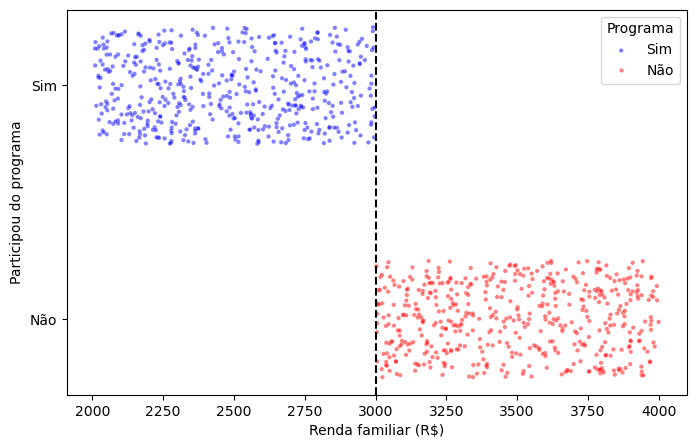

In [241]:
# Adicionando ruído
jitter = np.random.uniform(-0.25, 0.25, len(df))
df["tratamento_jitter"] = df["tratamento"].astype(int) + jitter  # Convertendo True/False para 1/0

# Criando o gráfico
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="renda_familiar", y="tratamento_jitter", hue="tratamento", palette=["red", "blue"], alpha=0.5, s=10)
plt.axvline(x=3000, color="black", linestyle="--")  # Linha vertical em x = 70
plt.xlabel("Renda familiar (R$)")
plt.ylabel("Participou do programa")
plt.yticks([0, 1], ["Não", "Sim"])  # Ajustando rótulos do eixo y
plt.legend(title="Programa", labels=["Sim", "Não"], loc="upper right")

Outra maneira de verificar isso é criando uma tabela. Como é visto, 497 estudantes não eram elegíveis e não participaram, por outro lado, 503 estudantes eram elegíveis e participaram. 

In [243]:
# Criando a coluna de elegibilidade
df["elegivel"] = df["renda_familiar"] <= 3000

# Agrupando por 'tratamento' e 'elegivel' e contando as ocorrências
table = df.groupby(["tratamento", "elegivel"]).size().reset_index(name="count")

# Exibindo a tabela
print(table)

   tratamento  elegivel  count
0           0     False    497
1           1      True    503


#### 5.1 Verificando se há descontinuidade no ponto de corte

Verificando se houve algum tipo de manipulação por parte das pessoas que participaram ou não do programa. Por exemplo, algumas pessoas podem ter mentido para os administradores do programa sobre a sua renda para poderem participar ou não do prgrama

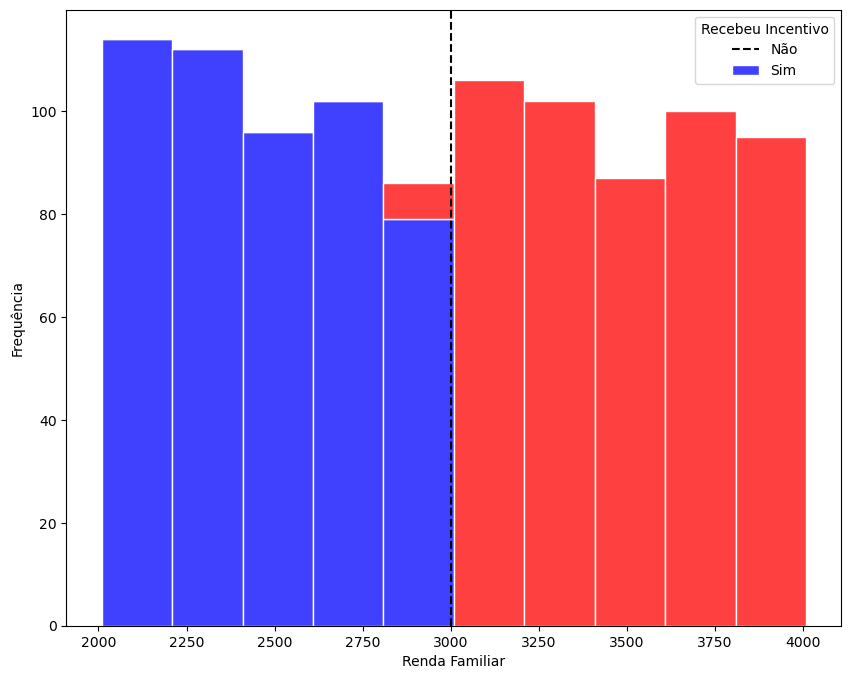

In [251]:
# Criando o gráfico com o DataFrame fornecido
plt.figure(figsize=(10, 8))
sns.histplot(df, x="renda_familiar", hue="tratamento", multiple="stack", 
             bins=range(int(df["renda_familiar"].min()), int(df["renda_familiar"].max()) + 200, 200), 
             palette=["red", "blue"], edgecolor="white")

# Adicionando linha vertical no cutoff de R$ 2500
plt.axvline(x=3000, color="black", linestyle="--")

# Rótulos e título
plt.xlabel("Renda Familiar")
plt.ylabel("Frequência")
plt.legend(title="Recebeu Incentivo", labels=["Não", "Sim"])

# Exibir o gráfico
plt.show()

O gráfico acima sugere que os estudantes ou administradores do programa não tentaram de alguma forma manipular as informações sobre a renda, para eventualmente, participar do programa. Isso é evidenciado pelo fato de que no ponto de corte não há uma grande diferença ou queda/aumento abrupto nas rendas familiares. Apesar da ferramenta gráfica permitir que tenhamos uma noção sobre a descontinuidade, talvez, ela não seja a ferramenta mais adequada. Para verficar tal hipótese podemos verificar se esse salto é estatisticamente significativo com um teste de densidade de McCrary.

A hipótese nula do teste de McCrary é de que não há manipulação, ou seja, que a descontinuidade no ponto de corte é igual a zero. Como o valor p é 0.4984, não podemos rejeitar a hipótese nula. Isso sugere que as rendas não foram "manipuladas" pelos estudantes para garantir ou evitar o acesso ao programa. **Há o gráfico, porém, não está funcionando em python**

In [253]:
# Realizando o teste de densidade de McCrary
teste_densidade = rddensity(df['renda_familiar'], c=3000)
teste_densidade

Manipulation testing using local polynomial density estimation
Number of obs:                              1000
Model:                              unrestricted
Kernel:                               triangular
BW method:                             estimated
VCE:                                   jackknife

c = 3000                            Left of c             Right of c
Number of obs:                            503                    497
Eff. number of obs:                       151                    232
Order est. (p):                             2                      2
Order bias. (q):                            3                      3
BW est.                              324.7477               454.1631

Method:                                     T                P > |T|
Robust                                  0.677                 0.4984

P-values of binomial tests (H0: p =  [0.5] ).

Window Length/2                           < c                     >= c                    

#### 5.2 Verifique se há descontinuidade no resultado em relação à variável de controle.

verificar se há uma descontinuidade no desempenho acadêmico com base na participação no programa. Pela imagem, observa-se um pequeno gap, que seria o impacto do programa. Porém, qual é o tamanho dessse impacto ?

In [254]:
# Criando o gráfico
plot = (
    ggplot(df, aes(x='renda_familiar', y='desempenho_academico', color='tratamento')) +
    geom_point(size=0.5, alpha=0.5) +
    geom_smooth(data=df[df['renda_familiar'] <= 3000], method='lm', se=True, color='black') +
    geom_smooth(data=df[df['renda_familiar'] > 3000], method='lm', se=True, color='black') +
    geom_vline(xintercept=3000) +
    labs(x='Renda familiar', y='Desempenho acadêmico', color='Usou tutoria') +
    theme(legend_position='none')
)

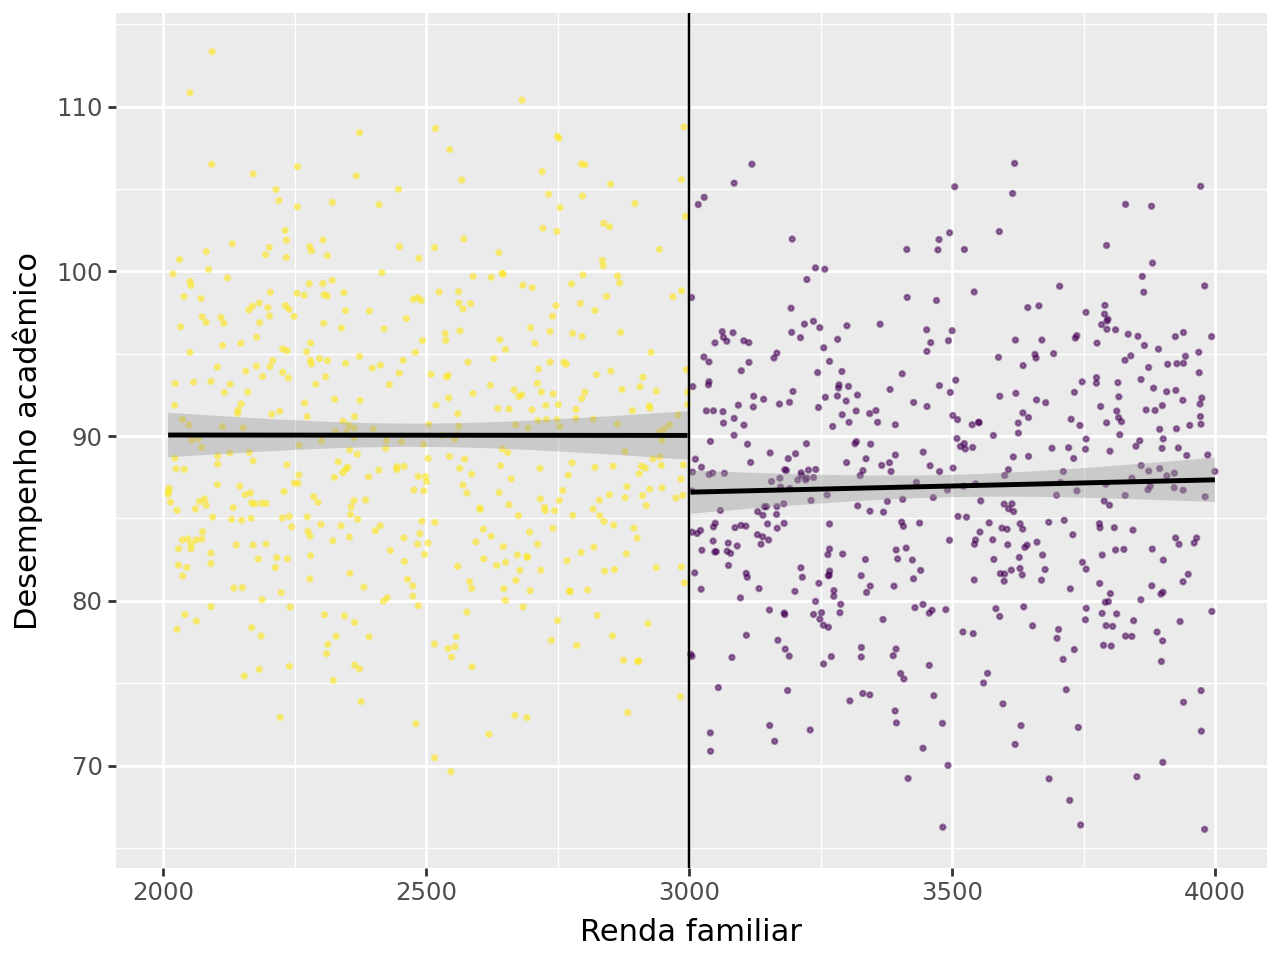

In [255]:
plot

### 6. Estimando o tamanho do efeito

A partir de agora será verificado o tamanho desse impacto e analisar se ele é significativo ou não.

#### 6.1 Estimação paramétrica

In [256]:
# Centralizando a variável 'renda_familiar' em torno de 3000
df['renda_familiar_centrada'] = df['renda_familiar'] - 3000

Ao centralizar `renda_familiar` após rodar a regressão, logo abaixo, o valor do coeficiente da constante é 86.7784. Isso significa que, quando renda_familiar_centrada é 0 (ou seja, a renda está exatamente no ponto de corte de 3000), o desempenho acadêmico médio será 86.7784, assumindo que o tratamento (por exemplo, o uso de tutoria) não é aplicado. Resumindo, `renda_familiar` foi centralizada para facilitar a interpretação

In [257]:
df.head()

,renda_familiar,nota_enem,num_irmaos,idade,tratamento,desempenho_academico,tratamento_jitter,elegivel,renda_familiar_centrada
0,2749.080238,474.053172,3,20,1,90.990577,1.181740,True,-250.919762
1,3901.428613,616.760379,2,22,0,82.470343,-0.095599,False,901.428613
2,3463.987884,749.178334,3,17,0,86.268121,-0.103233,False,463.987884
3,3197.316968,692.889955,1,24,0,92.708504,-0.117001,False,197.316968
4,2312.037281,722.624459,1,20,1,100.949503,0.916390,True,-687.962719


In [258]:
# Definindo as variáveis independentes (X) e dependente (y)
X = df[['renda_familiar_centrada', 'tratamento']]
X = sm.add_constant(X)  # Adiciona a constante (intercepto) ao modelo
y = df['desempenho_academico']

# Ajustando o modelo de regressão linear
model = sm.OLS(y, X).fit()

# Exibindo o resumo do modelo
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     desempenho_academico   R-squared:                       0.037
Model:                              OLS   Adj. R-squared:                  0.036
Method:                   Least Squares   F-statistic:                     19.40
Date:                  Wed, 26 Feb 2025   Prob (F-statistic):           5.44e-09
Time:                          19:40:28   Log-Likelihood:                -3479.4
No. Observations:                  1000   AIC:                             6965.
Df Residuals:                       997   BIC:                             6980.
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const 

Na estimação feita acima, não consideramos diferentes tamanhos de bandwidth, nem diferentes tipos de kernel. Essa não é a maneira ideal de verificar o real tamanho do impacto do programa. Como é visto o impacto do programa nesta condição foi de apenas 3.4690 pontos a mais no desempenho acadêmico, apesar de ser estatísticamente significativo, talvez, não seja realmente um aumento importante. Mas, ressalta-se, que esta não é a abordagem ideal para a medição do efeito do programa.

#### 6.2 Estimação Paramétrica bandwidth ± 250

Quando se utiliza o método RDD, é recomendado a escolha de bandwidth com diferentes valores, como indicado por ibens esta escolha pode ser feita atravez da validação cruzada, mas esse não é o único método para escolha de tal bandwidth. Abaixo consideraremos apenas aqueles estudantes que estão no intervalo entre 2750 e 3250. Como é visto na literatura, isto pode ser um defeito do RDD já que a quantidade de observações pode diminuir bastante.

In [260]:
# Filtrando os dados para incluir apenas entradas com 'renda_familiar_centrada' entre -250 e 250
df_bw250 = df[(df['renda_familiar_centrada'] >= -250) & (df['renda_familiar_centrada'] <= 250)]

# Definindo as variáveis independentes (X) e dependente (y)
X = df_bw250[['renda_familiar_centrada', 'tratamento']]
X = sm.add_constant(X)  # Adiciona a constante (intercepto) ao modelo
y = df_bw250['desempenho_academico']

# Ajustando o modelo de regressão linear
model = sm.OLS(y, X).fit()

# Exibindo o resumo do modelo
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     desempenho_academico   R-squared:                       0.042
Model:                              OLS   Adj. R-squared:                  0.034
Method:                   Least Squares   F-statistic:                     5.293
Date:                  Wed, 26 Feb 2025   Prob (F-statistic):            0.00562
Time:                          19:50:37   Log-Likelihood:                -843.97
No. Observations:                   245   AIC:                             1694.
Df Residuals:                       242   BIC:                             1704.
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const 

Com essa especificação de modelo, o programa teve um desempenho bem pior e não foi estatisticamente significativo.

#### 6.4 Estimação Paramétrica bandwidth ± 500

Abaixo consideraremos apenas aqueles estudantes que estão no intervalo entre 2500 e 3500

In [263]:
# Filtrando os dados para incluir apenas entradas com 'renda_familiar_centrada' entre -500 e 500
df_bw500 = df[(df['renda_familiar_centrada'] >= -500) & (df['renda_familiar_centrada'] <= 500)]

# Definindo as variáveis independentes (X) e dependente (y)
X = df_bw500[['renda_familiar_centrada', 'tratamento']]
X = sm.add_constant(X)  # Adiciona a constante (intercepto) ao modelo
y = df_bw500['desempenho_academico']

# Ajustando o modelo de regressão linear
model = sm.OLS(y, X).fit()

# Exibindo o resumo do modelo
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     desempenho_academico   R-squared:                       0.044
Model:                              OLS   Adj. R-squared:                  0.040
Method:                   Least Squares   F-statistic:                     11.27
Date:                  Wed, 26 Feb 2025   Prob (F-statistic):           1.64e-05
Time:                          19:52:50   Log-Likelihood:                -1703.5
No. Observations:                   488   AIC:                             3413.
Df Residuals:                       485   BIC:                             3426.
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const 

O programa continuou irrelevante para o desempenho acadêmico

#### 6.5 Estimação Paramétrica bandwidth ± 1000

In [265]:
# Filtrando os dados para incluir apenas entradas com 'renda_familiar_centrada' entre -1000 e 1000
df_bw1000= df[(df['renda_familiar_centrada'] >= -1000) & (df['renda_familiar_centrada'] <= 1000)]

# Definindo as variáveis independentes (X) e dependente (y)
X = df_bw1000[['renda_familiar_centrada', 'tratamento']]
X = sm.add_constant(X)  # Adiciona a constante (intercepto) ao modelo
y = df_bw1000['desempenho_academico']

# Ajustando o modelo de regressão linear
model = sm.OLS(y, X).fit()

# Exibindo o resumo do modelo
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     desempenho_academico   R-squared:                       0.037
Model:                              OLS   Adj. R-squared:                  0.036
Method:                   Least Squares   F-statistic:                     19.40
Date:                  Wed, 26 Feb 2025   Prob (F-statistic):           5.44e-09
Time:                          20:08:00   Log-Likelihood:                -3479.4
No. Observations:                  1000   AIC:                             6965.
Df Residuals:                       997   BIC:                             6980.
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const 

Novamente, sem muita relevância.

### 7. Testando a robustez

Como indicado pelo artigo, é importante verificar várias especificações com diferentes covariáveis. Entretanto, por termos um conjunto de dados simulados relativamente simples, diferentes tipos de especificações não serão testados aqui, porém, podemos testar como o programa se comporta quando analisado de forma não paramétrica e com diferentes tipos de kernel.

#### 7.1 Não paramétrico sem definição de bandwidth

In [278]:
# Estimando o efeito de descontinuidade de regressão
nparam = rdrobust(df['desempenho_academico'], df['renda_familiar'], c=3000, kernel = 'triangular')
nparam

Call: rdrobust
Number of Observations:                  1000
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           503        497
Number of Unique Obs.            503        497
Number of Effective Obs.         155        182
Bandwidth Estimation         330.786    330.786
Bandwidth Bias                493.09     493.09
rho (h/b)                      0.671      0.671

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       -2.31     1.89   -1.222   2.215e-01    [-6.014, 1.394]
Robust                 -        -   -1.004   3.154e-01    [-6.832, 2.204]


O coeficiente `Conventional` indica o impacto do programa, apesar do sinal negativo, para este caso, ele indica os alunos que participaram do programa tiveram um aumento de 2.31 pontos. novamente, apesar de ser estatisticamente significativo, o efeito parece ser bem irrelevante. o Kernel ajustado na célula acima foi do tipo triangular (default). podem ser utilizados também a do tipo 'uniforme' e 'epanechnikov'

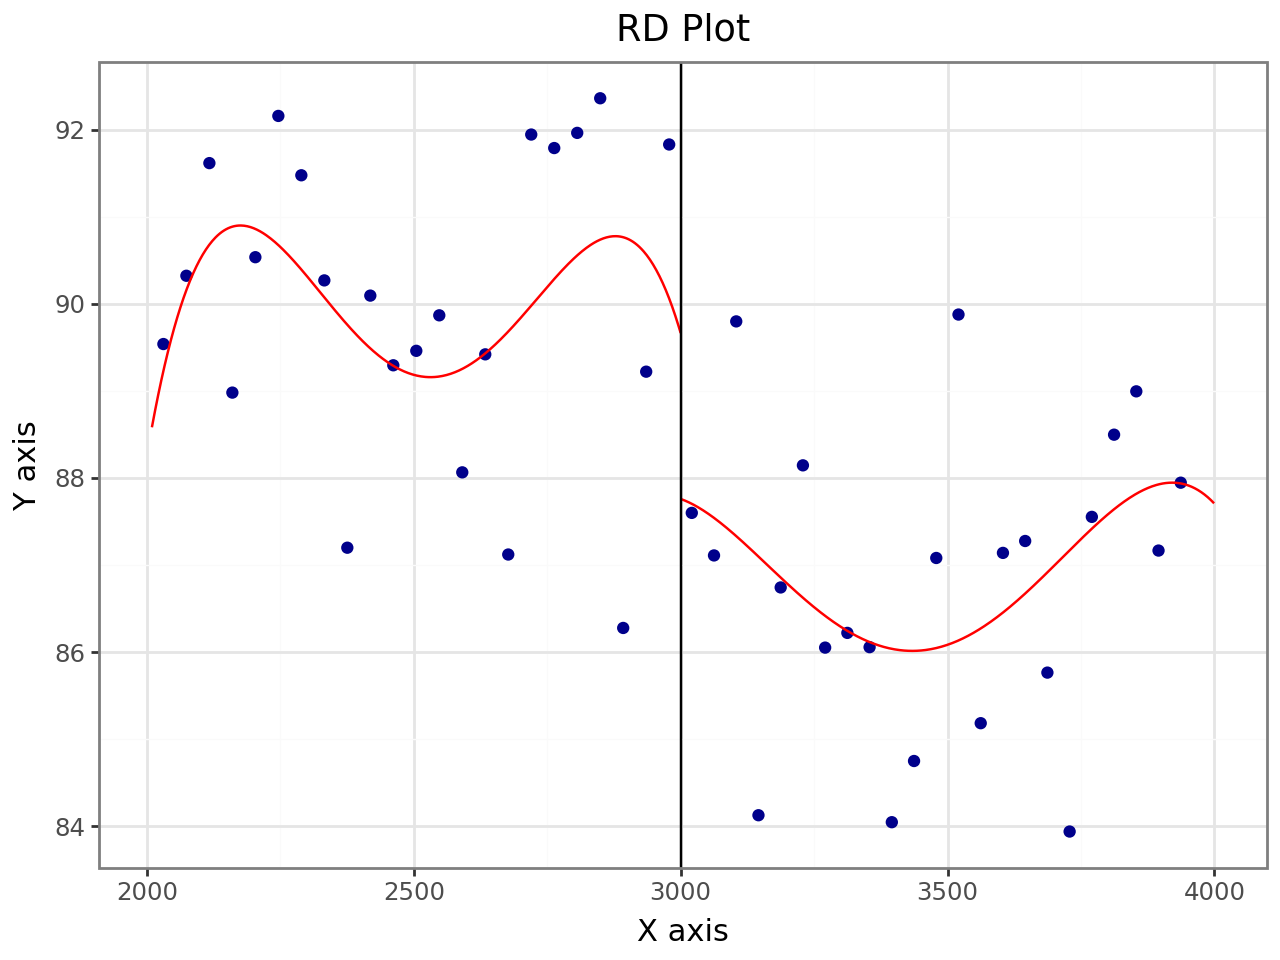

Call: rdplot
Number of Observations:                  1000
Kernel:                               Uniform
Polynomial Order Est. (p):                  4

                                Left      Right
------------------------------------------------
Number of Observations           503        497
Number of Effective Obs          503        497
Bandwith poly. fit (h)       990.736    999.435
Number of bins scale               1          1
Bins Selected                     23         24
Average Bin Length            43.075     41.643
Median Bin Length             43.075     41.643
IMSE-optimal bins                6.0        4.0
Mimicking Variance bins         23.0       24.0

Relative to IMSE-optimal:
Implied scale                  3.833        6.0
WIMSE variance weight          0.017      0.005
WIMSE bias weight              0.983      0.995


In [276]:
# Plote do modelo não paramétrico
rdplot(df['desempenho_academico'], df['renda_familiar'], c=3000, hide = False)

#### 7.3 Selecionando o melhor bandwidth

Como mostrado abaixo, o algoritimo indicou vário valores de bandwidth. Vou utilizar apenas o primeiro.

In [280]:
rdbwselect(y=df['desempenho_academico'], x=df['renda_familiar'], all=True, c=3000)

Call: rdbwselect
Number of Observations:                  1000
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                      All
Var-Cov Estimator:                         NN

          h (left)  h (right)  b (left)  b (right)
mserd      330.786    330.786   493.090    493.090
msetwo     339.808    377.237   512.330    566.368
msesum     405.575    405.575   609.948    609.948
msecomb1   330.786    330.786   493.090    493.090
msecomb2   339.808    377.237   512.330    566.368
cerrd      234.179    234.179   493.090    493.090
certwo     240.566    267.063   512.330    566.368
cersum     287.125    287.125   609.948    609.948
cercomb1   234.179    234.179   493.090    493.090
cercomb2   240.566    267.063   512.330    566.368


##### 7.3.1 Modelo não paramétrico com Bandwidth de 330.76 e kernel triangular

In [282]:
np_triangular = rdrobust(df['desempenho_academico'], df['renda_familiar'], c=3000, h = 330.786, kernel = 'triangular')
np_triangular

Call: rdrobust
Number of Observations:                  1000
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                   Manual
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           503        497
Number of Unique Obs.            503        497
Number of Effective Obs.         155        182
Bandwidth Estimation         330.786    330.786
Bandwidth Bias               330.786    330.786
rho (h/b)                        1.0        1.0

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       -2.31     1.89   -1.222   2.215e-01    [-6.014, 1.394]
Robust                 -        -   -1.357   1.747e-01    [-9.586, 1.741]


##### 7.3.2 Modelo não paramétrico com Bandwidth de 330.76 e kernel uniform

In [283]:
np_uniform = rdrobust(df['desempenho_academico'], df['renda_familiar'], c=3000, h = 330.786, kernel = 'uniform')
np_uniform

Call: rdrobust
Number of Observations:                  1000
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                               Uniform
Bandwidth Selection:                   Manual
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           503        497
Number of Unique Obs.            503        497
Number of Effective Obs.         155        182
Bandwidth Estimation         330.786    330.786
Bandwidth Bias               330.786    330.786
rho (h/b)                        1.0        1.0

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -2.399    1.632    -1.47   1.415e-01    [-5.597, 0.799]
Robust                 -        -   -0.843   3.993e-01    [-7.296, 2.908]


##### 7.3.3 Modelo não paramétrico com Bandwidth de 330.76 e kernel epanechnikov

In [288]:
np_epanechnikov = rdrobust(df['desempenho_academico'], df['renda_familiar'], c=3000, h = 330.786, kernel = 'epanechnikov')
np_epanechnikov

Call: rdrobust
Number of Observations:                  1000
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                          Epanechnikov
Bandwidth Selection:                   Manual
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           503        497
Number of Unique Obs.            503        497
Number of Effective Obs.         155        182
Bandwidth Estimation         330.786    330.786
Bandwidth Bias               330.786    330.786
rho (h/b)                        1.0        1.0

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -2.026    1.781   -1.138   2.553e-01    [-5.515, 1.464]
Robust                 -        -   -1.199   2.306e-01    [-8.786, 2.117]


Como é visto, independente da especificação o programa parece não ser relevante.